In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

## Module 1

### Least - squares fit

Minimize the sum of squares of the errors: 

$min \sum_{k=0}^{m} e_k^2=min \sum_{k=0}^{m} (F(x_k)-y_k)^2$

#### Example


finding a and b in F(x)=ax+b, which give the linear least-squares fit:

$\varphi (a,b)$, $\varphi(a,b)=\sum_{k=0}^m(a x_k+b -y_k)^2$.

Necessary conditions at the minimum: $\frac{\partial \varphi}{\partial a}=0$ and $\frac{\partial \varphi}{\partial b}=0$, which leads to 

$\sum_{k=0}^m2(a x_k+b -y_k)x_k=0$, $\sum_{k=0}^m2(a x_k+b -y_k)=0$

The coefficient pair (a,b) is the solution of the normal equations:

$\begin{bmatrix} s & p \\ p & m+1 \end{bmatrix} \begin{bmatrix}a \\ b \end{bmatrix}=\begin{bmatrix}r\\ q\end{bmatrix}$ 
$
\begin{cases}
p = \sum_{k=0}^{m} x_k, \qquad 
r = \sum_{k=0}^{m} x_k y_k \\[6pt]
q = \sum_{k=0}^{m} y_k, \qquad 
s = \sum_{k=0}^{m} x_k^{2}
\end{cases}
$

Define $A=\begin{bmatrix} x_0 & 1 \\ x_1 & 1 \\ x_2 & 1 \\ . & .\\. & .\\. & .\\ x_m & 1\end{bmatrix}$, $c=\begin{bmatrix}a\\ b \end{bmatrix}$, $y=\begin{bmatrix}y_0 \\ y_1 \\ y_2 \\ . \\ . \\ . \ y_m\end{bmatrix}$

The normal equations can be written as:
$(A^TA)c=A^Ty$


#### Example 

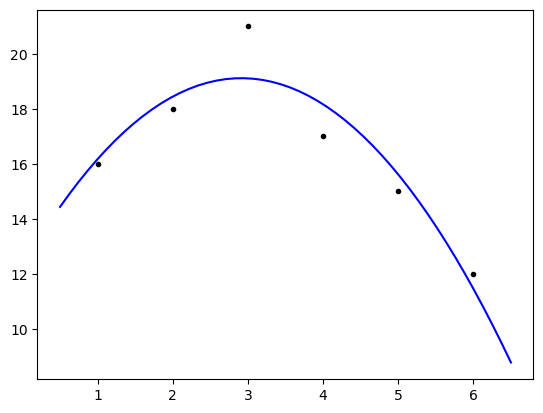

In [ ]:
#fit with poynomial: polyfit
#in this example we fit with F(x)=ax^2+bx+c

m=2 #set the degree of the polynomial
x=np.arange(1,7)
y=np.array([16,18,21,17,15,12])
c=np.polyfit(x,y,m)
xx=np.linspace(0.5,6.5)
yy=np.polyval(c,xx)
plt.plot(x,y,'.k',xx,yy,'-b')
plt.show()

#### Exercise

Fit the data by a function: 

$F(x)=c_0+c_1x+c_2sin(x)+c_3cos(x)+c_4sin(2x)+c_5cos(2x)$

Calculate the least-squares fit, indicate the estimated coefficients and plot the fit function with the data points.

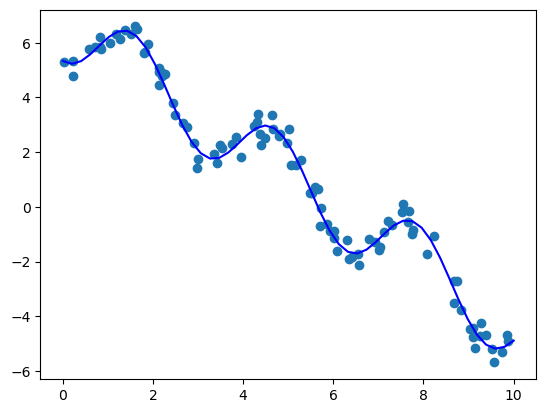

In [ ]:
xy=np.load('FitData.npy') #reading the file with data points
x=xy[:,0]
y=xy[:,1]
A=np.array([np.ones_like(x), x, np.sin(x), np.cos(x), np.sin(2*x), np.cos(2*x)]).T
c=np.linalg.solve(A.T@A, A.T@y) #solving normal equation
xx=np.linspace(0,10) #the given data goes is in the interval of (0,10)
yy=c[0]*1+c[1]*xx+c[2]*np.sin(xx)+c[3]*np.cos(xx)+c[4]*np.sin(2*xx)+c[5]*np.cos(2*xx)
plt.plot(x,y,'o', xx,yy,'-b')

### Horner's algorithm (method)

An efficient technique for evaluating polynomials and is widely used in numerical computation because it minimizes the number of multiplications.

For example, to evaluate the polynomial: 

$p(x)=a_0+a_1x+a_2x^2+...+a_{n-1}x^{n-1}+a_nx^n$

Require n additions and $\frac{1}{2}n(n+1)$ multiplications.

$p(x)=a_0+x(a_1+x(a_2+...+x(a_{n-1}+xa_n)...))$ 

Require n additions and only n multiplications.

In [ ]:
def Horners_algorithm(a,x):
  n=len(a)-1
  p=a[n]
  for i in range(n-1,-1,-1):
    p=a[i]+x*p
  return p

### Absolute and relative errors

Absolute error: 

$a-\varepsilon \leq \overline{a} \leq a+ \varepsilon$, $\overline{a}$ - approximation

Relative error:

$\frac{|a-\overline{a}|}{|a|} \leq \varepsilon$

### Multiple root

Simple root: $\textcolor{lightgreen}{f(r)=0}$ and $\textcolor{pink}{f_1'(x)\neq 0}$: $f_1(x)=sin(x)$ => $f_1'(x)=cos(x)$

Double root: $\textcolor{lightgreen}{f(r)=f'(r)=0}$ and $\textcolor{pink}{f''(r) \neq 0}$:

$f_2(x)=xsin(x)$ => $f_2'(x)=sin(x)+xcos(x)$, $f_2''(x)=2cos(x)-xsin(x)$

Triple root: $\textcolor{lightgreen}{f(r)=f'(r)=f''(r)=0}$ and $\textcolor{pink}{f^{(3)}(r) \neq 0}$:

$f_3(x)=sin^2(x)$ => $f_3^{(3)}(3)=6cos^3(x)-21cos^2(x)sin(x)$

### Bisection algorithm

Bisection algorithm reduces the width of the interval by half in each iteration. 

Absolute error after n iterations: $|r-c|\leq \frac{b-a}{2^{n+1}}$ 

Start-interval: [a,b]

Compute: fa=f(a), fb=f(b)

Repeat until b-a is small enough:

*Compute the midpoint $c=\frac{1}{2}(a+b)$ and fc=f(c)

*if $fa \cdot fc <0$ (A root exists between a and c): b=c and fb=fc

**otherwise: a=c and fa=fc

*Compute root: $c=\frac{1}{2}(a+b)$


In [ ]:
def Bisection (f,a,b,nmax):
  fa=f(a)
  fb=f(b)
  if np.sign(fa)!=np.sign(fb):
    error=b-a
    for i in range(0,nmax):
      error=error/2
      c=a+error
      fc=f(c)
      if np.sign(fa)!=np.sign(fc):
        b=c
        fb=fc
      else:
        a=c
        fa=fc
  return c

Some disadvantages of the bisection algorithm:

-it is robust but converges slowly

-it cannot find some multiple roots

-if f is not continuous, we cannot use bisection algorithm

-it cannot be generalized to the case with more than one variable

Number of iterations can be found by:

$n=\frac{log(b-a)-log(2\epsilon)}{log 2}$, where $\epsilon$ is tolerance. (the result of n is rounded up)

### Newton's method

We start with an approximation $x_0$. The next approximation $x_1$ is the intersection of the line $l(x)=f'(x_0)(x-x_0)+f(x_0)$ with the x-asix. That is, set l(x)=0, and obtain $x_1=x_0-\frac{f(x_0)}{f'(x_0)}$.

Naturally, this process can be repeated to produce a sequance:

$x_2=x_1-\frac{f(x_1)}{f'(x_1)}$, $x_2=x_1-\frac{f(x_2)}{f'(x_2)}$, ...

Based on Taylor's Theorem at $x=x_0$ we have:

$f(x_0+h)=f(x_0)+hf'(x_0)+\frac{1}{2}h^2f''(x_0)+...$

We want to find h such that $f(x_0+h)=0$, but it's not easy. Thus, we ignore all higher-order terms in Taylor series and find h satisfying 

$f(x_0)+hf'(x_0)=0$ which gives $h=-\frac{f(x_0)}{f'(x_0)}$

In [ ]:
def Newton(f, df, x, nmax):
  X=np.array([x])
  for i in range(1,nmax+1):
    fx=f(x)
    fp=df(x)
    x=x-fx/fp
    X=np.append(X,x)
  return X

The convergence of Newton's method depends on the hypothesis that the starting point $x_0$ is sufficiently close to a root. If $x_0$ is abit far away from r, the method can fail. When the starting point is suffficiently close to a root, Newton's method converges fast.

Convergent rate is quadratic, according to

$|e_{n+1}|=\frac{1}{2}|\frac{f''(\xi_n)}{f'(x_n)}|e_n^2 \leq c(\delta)e_n^2 \leq c(\delta) |e_n| \delta = \delta c(\delta) |e_n|$, 

where $c(\delta) \equiv \frac{1}{2} \frac{max_{|r-x| \leq \delta}|f''(x)|}{min_{|r-x| \leq \delta}|f'(x)|}$

Newton's method is not robust, meaning it is sensitive to small changes.

Exercise from Homework 1 where we had to modify Newton method. We introduce new variable m - multiplicity of the zero.

In [ ]:
def Modified_Newton(f, df, x, nmax, m):
  X1=np.array([x])
  y=x
  X2=np.array([y])
  for i in range(1,nmax+1):
    if abs(df(x))<1e-10:
      print(f'derivative is near zero in standard Newton method')
      break
    if abs(df(y))<1e-10:
      print(f'derivative is near zero in modified Newton method')
      break
    x=x-f(x)/df(x)
    y=y-m*f(y)/df(y)
    X1=np.append(X1,x)
    X2=np.append(X2,y)
  return X1,X2

To show that the method converges quadratically we can plot a loglog plot of errors and if it's a linear graph with around slope of 2, then we know it to converge quadratically.

### Secant method

We approximate $f'(x_n)$ by the slope of the secant line of two points $x_{n-1}$ and $x_n$.

__Graphical__. The equation of the secant line from $(x_{n-1},f(x_{n-1}))$ and $(x_n,f(x_n))$ is:

$y=f(x_n)+\frac{f(x_{n-1})-f(x_n)}{x_{n-1}-x_n}(x-x_n)$

If we set y=0, then we obtain

$x=x_{n+1}=x_n-f(x_n)\frac{x_{n-1}-x_n}{f(x_{n-1})-f(x_n)}$

In [ ]:
def secant(f, x0, x1, nmax):
  a=x0
  b=x1
  fa=f(a)
  fb=f(b)
  X=np.array([a])
  X=np.append(X, b)
  for i in range (2, nmax+1):
    d=fb*((b-a)/(fb-fa))
    a=b
    fa=fb
    b=b-d
    fb=f(b)
    X=np.append(X,b)
  return X

The method has superlinear convergence, which is faster than linear:

the order of convergence of the secant method can be expressed in terms of the inequality $|e_{n+1}| \leq C|e_n|^\phi$, where $\phi=\frac{1}{2}(1+\sqrt5)\approx 1.62$. And because $\phi>1$ we say it is superlinear convergence.

### Comparison of methods 

__Bisection__ is robust but slow. If an error tolerance has been given in advance, the number of iterations required by bisection method can be estimated.

__Bisection__ requires two starting points with different signs of f(x), and f only need to be continuous.

__Newton's method__ requires $f'$.

__Newton's method__ and __secent method__ converges faster than bisection method, but require a starting point that is "sufficiently close" to a root. 

__Secant method__ is nearly as fast as Newton's method and does not require knowledge of the derivative $f'$.

__All methods__ requires the user to know roughly about the desired root and how many roots to be examined.

## Module 2

### Polynomial Interpolation

__Nodes__ a set of n+1 distinct points of $x_i$, i.e. $x_i \neq x_j$ if $i \neq j$

A function p __interpolates__ data $(x_0,y_0), (x_1,y_1),...,(x_n,y_n)$, if 

$p(x_i)=y_1$ for i=0,...,n

__Cardinal polynomials__ $l_i(x)=\prod_{j=0,j \neq i}^n\lambda_{i,j}(x)=\prod_{j=0,j \neq i}^n(\frac{x-x_j}{x_i-x_j})$, where $\lambda_{i,j}$ satisfies $\lambda_{i,j(x_i)=1}$ and $\lambda_{i,j(x_j)=0}$. Hence, the cardinal polynomial $l_i$ has the property 

$l_i(x_j)=\delta_{ij}=
\begin{cases}
1,if_{} i=j \\[6pt]
0, if i\neq j 
\end{cases}
$

In [ ]:
def CardinalPolynomial(nodes, i, t):
  m=len(nodes)
  t=np.array(t)
  L=np.ones_like(t)
  for j in range (0,m):
    if j!=i:
      L*=(t-nodes[j])/(nodes[i]-nodes[j])
  return L

__Lagrange form__ of the interpolation polynomial is $p_n(x)=\sum_{i=0}^nl_i(x)y_i$

We can approximate any function, f, by interpolating a table of its values.

In [ ]:
def InterpolerLagrangeForm(nodes, ydata, t):
  cardinals=[]
  t=np.array(t,dtype=float)
  m=len(ydata)
  for i in range (m):
    cardinals.append(CardinalPolynomial(nodes,i,t))
  np.asarray(cardinals)
  P=np.zeros_like(t,dtype=float)
  for i in range (m):
    P+=cardinals[i]*ydata[i]
  return P

Interpolating polynomial: __Newton algorithm__ 

We construct a sequence of polynomials, each of which interpolates one more pair of values in the table than the predecessor.

Assume that the polynomial $p_k$ is of degree at most k and interpolates the first k + 1 < n pairs of values in the table, i.e. $p_k(x_i)=y_i$ for i=0,...,k.  Now we consider 

$P(x)=p_k(x)+c(x-x_0)(x-x_1)...(x-x_k)$. 

P(x) is of degree at most (k+1), and the constant c can be uniquely determined by $P(x_k+1)=p_k(x_k+1)+c(x_{k+1}-x_0)(x_{k+1}-x_1)...(x_k+1-x_k)=y_{k+1}$.

Then, we have $p_{k+1}=P$

The Newton form and Lagrange form are just two different derivations for precisely the same polynomial.

Based on the Newton algorithm we can rewrite the interpolating polynomial by "nested multiplication".

The Lagrange form consists of n+1 cardinal polynomials of degree n. To evaluate each cardinal polynomial, we need 2n subtractions, n, divisions and n-1 multiplications. So to evaluate the whole Lagrange form we need 4n(n+1)+n flops (floating point operations).

Newton algorithm provides interpolation polynomials in a nested multiplication, which need much less flops for evaluation. Nested multiplication only requires 3n flops.

### Vardermonde matrix

Another way to finding a polynomial to interpolate a table is to solve n+1 equations, $p_n(x_i)=y_i$ with n+1 unknown coefficients $c_0,c_1,...,c_n$. This can be written as a linear system:

$\begin{bmatrix}
1&x_0&x_0^2&...&x_0^n\\
1&x_1&x_1^2&...&x_1^n\\
1&x_2&x_2^2&...&x_2^n\\
.&.&.&.&.\\
1&x_n&x_n^2&...&x_n^n\end{bmatrix}
\begin{bmatrix}c_0\\c_1\\c_2\\.\\ c_n\end{bmatrix}=
\begin{bmatrix}y_0\\y_1\\y_2\\.\\ y_n\end{bmatrix}$

The coefficient matrix is called a Vandermonde matrix.

### Inverse interpolation

If we reverse the arguments x and y=f(x) in the table interpolation, then we could ontain an approximation, x=p(y), of the inverse functions $f^{-1}(y).

Inverse interpolation can be used to find a root of the given functions: we create a table of values $(f(x_i),x_i)$ and interpolate with a polynomial, p. Thus, we obtain $p(y_i)=x_i$ and the approximate root is then given by p(0). (the points should be chosen near the root).

In [ ]:
def MyInverseQuadraticInterpolation(f, x, n):
  x_all = np.array(x, dtype=float).tolist()

  for k in range(n):
      # Current three points
      x1, x2, x3 = x_all[-3:]
      y1, y2, y3 = f(x1), f(x2), f(x3)

        # Interpolate inverse: nodes = [y1, y2, y3], values = [x1, x2, x3]
        # We want p(0)
      x4 = InterpolerLagrangeForm([y1, y2, y3], [x1, x2, x3], [0])[0]
      x_all.append(x4)

  return np.array(x_all[3:])

### Errors in polynomial interpolation

A polynomial of degree n has n zeros, i.e., its curve crosses the x-azis n times, which results in wild oscillations.

__First Interpolation Error Theorem:__ If $p_n$ is the polynomial of degree at most n that interpolates f at the n+1 distinct nodes $x_0,x_1,...,x_n \in [a,b]$ and $f^{(n+1)}$ is continuous, then for each $x \in [a,b]$, there is a $\xi \in (a,b)$ for which 

$f(x)-p_n(x)=\frac{1}{(n+1)!}f^{(n+1)}(\xi)\prod_{i=0}^n(x-x_i)$

__Second Interpolation Error Theorem:__ Let f be a function such that $f^{(n+1)}$ is continuous on [a,b] and satisfies $|f^{(n+1)}(x)| \leq M$. Let $p_n$ be the polynomial of degree at most n that interpolates f at the n+1 equally spaced nodes in [a,b], including the endpoints. The, for all $x\in [a,b]$, we have

$|f(x)-p_n(x)| \leq \frac{1}{4(n+1)}|f^{(n+1)}(\xi)|h^{n+1} \leq \frac{1}{4(n+1)}Mh^{n+1}$

where $h=\frac{b-a}{n}$ is the spacing between nodes.

### Numerical integration

__Approximation through interpolating polynomials__ 

The approximation of the integration f is 

$I=\int_a^b f(x)dx \approx \int_a^b p_n(x)dx=\int_a^b \sum_{i=0}^nl_i(x)f(x_i)dx=$

$\sum_{i=0}^nf(x_i)\int_a^bl_i(x)dx=\sum_{i=0}^nf(x_i)A_i$,

 where the constants, $A_i=\int_a^bl_i(x)dx, i=0,...,n$ can be predetermined.

The approximation of the integral is just a weighted linear combination of the function values $f(x_0),f(x_1),...,f(x_n)$. 

__Newton-Cotes formulas__ For n+1 equally spaced nodes $x_i=a+ih$, where $h=\frac{b-a}{n}$, with predetermined $A_i$ we obtain the Newton-Cotes quadrature formula.

$|\int_a^bf(x)dx-\int_a^bp_n(x)dx|\leq\int_a^b|f(x)-p_n(x)|dx\leq(b-a)\frac{1}{4(n+1)}Mh^{n+1}$ 

(but we can get even btter error estimation for specific n)

__Trapezoid rule__ 

$\int_a^bf(x)dx\approx \int_a^bp_1(x)dx=\int_a^b(f(a)l_0(x)+f(b)l_1(x))dx=$

$f(a)\int_a^bl_0(x)dx+f(b)\int_a^bl_1(x)dx=f(a)\frac{b-a}{2}+f(b)\frac{b-a}{2}=h\frac{1}{2}(f(a)+f(b))$,

where h=(b-a)/1

$I=\int_a^bf(x)dx=h\frac{1}{2}(f(a)+f(b))+E_t$, where h=b-a and $E_t$ is truncation error.

$E_t=-\frac{1}{12}h^3f''(\xi)$, where h=b-a and $\xi$ is an unknown value between a and b. Thus,

$|E_t|\leq\frac{1}{12}h^3max|f''(\xi)|$.

Hence, the error is large if $|f''(\xi)|$ is large, or h is large. 

__Composite trapezoid rule__

If f'' exist and is continuous in the interval [a,b] and if the interval is divided into n equal subintervals with points $x_i=a+ih$ and spacing $h=\frac{b-a}{n}$, the the composite trapeziod rule is

$\int_a^bf(x)dx=h(\frac{1}{2}f_0+f_16f_2+...+f_{n-1}+\frac{1}{2}f_n)+E_t$, where the error term is

$E_t=-\frac{(b-a)h^2}{12}(\frac{1}{n}\sum_{i=1}^nf''(\xi_i))=-\frac{(b-a)h^2}{12}f''(\zeta)$ with $a<\zeta<b$.

The error is $O(h^2)$, i.e., it is proportional to $h^2$ and $\frac{1}{n^2}$.

In [1]:
def MinTrapez(f, a, b, n):
  x=np.linspace(a,b,n+1)
  h=(b-a)/n
  sum=0
  for i in range(len(x)):
    if (i==0 or i==len(x)-1):
      sum=sum+0.5*f(x[i])
    else:
      sum=sum+f(x[i])

  return h*sum

__Simpson's rule__

$I=\int_a^bf(x)dx\approx\int_a^bp_2(x)dx=\int_a^b\sum_{i=0}^2l_i(x)f(x_i)dx=$

$\sum_{i=0}^2f(x_i)\int_a^bl_i(x)dx=\frac{h}{3}(f(x_0)+4f(x_1)+f(x_2))$, $h=\frac{b-a}{2}$

Simpson's rule is designed to give correct values for the integral of a polynomial of degree at most 2. (and of the polynomial of degree 3)

We can apply Taylor series to obtain the error term of Simpson's rule

$E_t=-\frac{h^5}{90}f^{(4)}(\xi)=-\frac{(b-a)^5}{2880}f^{(4)}(\xi)$,  $a<\xi<b$

__Composite Simpson's rule__

Similar to the composite trapezoid rule, we can divide [a,b] into n subintervals, each of width $h=\frac{b-a}{n}$ and write

$\int_a^bf(x)dx=\int_{x_0}^{x_2}f(x)+\int_{x_2}^{x_4}f(x)dx+...+\int_{x_{x-2}}^{x_n}f(x)dx=$

$\sum_{i=1}^{n/2}(\frac{h}{3}(f_{2i-2}+4f_{2i-1}+f_{2i})-\frac{h^5}{90}f^{(4)}(\eta_i))=$
$\frac{h}{3}(f_0+4f_1+2f_2+4f_3+...+2f_{n-2}+4f_{n-1}+f_n)+E_t$, 

where $E_t=-\frac{b-a}{180}h^4f^{(4)}(\xi)=-\frac{(b-a)^5}{180n^4}f^{(4)}(\xi)$, $a<\xi<b$.

The error is proportional with $h^4$ and $\frac{1}{n^4}$.

n must be even!!!

In [ ]:
def MySimpson (f, a, b, n):
  if n%2!=0:
    print("Error")
    return np.nan
  x=np.linspace(a,b,n+1)
  h=(b-a)/n
  sum=0
  for i in range(n+1):
    if(i==0 or i==n):
      sum=sum+f(x[i])
    elif(i%2==0):
      sum=sum+2*f(x[i])
    else:
      sum=sum+4*f(x[i])

  return (h/3)*sum

Simpson's and trapezoid rules require same amount of computation but Simpson's rule provide better accuracy.

Generally, it doesn't help to increase the degree of the approximating polynomial in the composite formulas. But adaptive algorithms are preferable.

__Adaptive algorithm__ 

*fewer and larger subintervals where f is "simple" (varies less)

*more and smaller subintervals where f varies a lot.

The partitioning of the interval is automatically determined and is generated adaptively based on the function.

__Recursive adaptive integration__

Assume that we have an approximation $l_1$ with an error E: $\int_a^bf(x)dx=I_1+E$.

If the error E is too large, we divde [a,b] into two subintervals [a,c] and [c,b] with the midpoint c=(a+b)/2:

$\int_a^b f(x)dx=\int_a^cf(x)dx+\int_c^bf(x)dx=I_L+E_L+I_R+E_R$.

If the total error $E_L+E_R$ is sufficiently small, then $I_2=l_L+I_R$ is an acceptable approximation to the integral.

Recursive strategy: use the same idea to approximate $I_L$ and $I_R$.

The same process can be done with error estimation.

__Procedure__

Calculate the approximations $I(h_1)$ and $I(h_2)$ with Simpson's rule and the length of the interval $h_1=(b-a)/2$ and $h_2=(b-a)/4$. Then we use Richardson-extrapolation to calculate a better approximation to the integral, 

$I_3=I(h_2)+\frac{1}{15}(I(h_2)-I(h_1))$ and $|I_3-I(h_2)|=\frac{1}{15}|I(h_2)-I(h_1)|$ is the error estimate for $I(h_2)$.

_If_ the error estimate is less than $\tau$ (given in advance), then stop.

_Otherwise_, repeat the process on each of the subintervals, [a,c] and [c,b], with c=(a+b)/2. On each subinterval, the tolerance $\tau$ is replace by $\tau/2$.

In [ ]:
def integrer (f,a,b,tol,I1):
  c=(a+b)/2
  IL=MySimpson(f,a,c)
  IR=MySimpson(f,c,b)
  I2=IL+IR
  I=I2+(I2-I1)/15

  if abs(I-I2)>tol:
    IL=integrer(f,a,c,tol/2,IL)
    IR=integrer(f,c,b,tol/2,IR)
    I=IL+IR
  
  return I

__Gaussian Quadrature Theorem:__ Let q be a nontrivial polynomial of degree n+1 such that 

$\int_a^b x^kq(x)dx=0$, k=0,1,...,n.

Let $x_0,x_1,...,x_n$ be the zeros of q. The, the formula

$\int_a^bf(x)dx\approx\sum_{i=0}^nA_if(x_i)$, where $A_i=\int_a^bI_i(x)dx$ with these $x_i$'s as nodes will be exact for all polynomials of degree at most 2n+1

## Module 3

### Initial values problems

__Higher-order differential equation -> system of first order__

A differential equation
$
\frac{d^n x}{dt^n} = f\!\left(t,\, x,\, \frac{dx}{dt},\, \ldots,\, \frac{d^{\,n-1}x}{dt^{\,n-1}}\right)
$

of order n>1 can always be written as a system of n first-order differential equations.

We define n new variables $z_1, z_2, \ldots, z_n$ as follows:

$
z_1 = x,\qquad
z_2 = \frac{dx}{dt},\qquad
\ldots,\qquad
z_n = \frac{d^{\,n-1}x}{dt^{\,n-1}}.
$

Then

$
\frac{dz_1}{dt} = z_2,
\qquad
\frac{dz_2}{dt} = z_3,
\qquad
\ldots,
\qquad
\frac{dz_n}{dt}
= f\!\left(t,\, x,\, \frac{dx}{dt},\, \ldots,\, \frac{d^{\,n-1}x}{dt^{\,n-1}}\right).
$

These are n coupled first-order differential equations, and can be written in general vector notation as

$
\frac{d\mathbf{z}(t)}{dt} = \mathbf{f}\!\left(t,\, \mathbf{z}(t)\right),
$ 

where $\mathbf{z}(t) = (z_1,\ldots,z_n)^\top.$


__Existance and uniqueness to solutions__

The theorem on existance and uniqueness to solutions for differential equations only shows time-related local existance. The is, we only can conclude that the solution exist in an (small) opan time interval which contains starting time.

#### Euler's method

The formula of Euler's method is $x(t+h)=x(t)+hf(t,x(t))$.

Note that x(t+h) lies on the tangent line to the graph of x at (t,x(t)).

Split the interval [a,b] into n subintervals with size h=(b-a)/n. Euler's method starts from $x(a)=x_a$ and after n steps

$x(a) \rightarrow x(a+h) \rightarrow x(a+2h) \rightarrow ... \rightarrow x(a+nh)=x(b)$

end with an approximation of x(b).

The next point always lies on the tangent line to the previous point; the points from Euler's method cannot turn fast enough when x is convex or cancave.

Euler's method is not common used in pratice.

All the following methodscan be considered as generalized Euler's method.

In [ ]:
def MyEuler(dxdt, tspan, x0, n):
    a, b = tspan
    t = np.linspace(a, b, n+1)
    h = (b - a) / n # h is calculated only once
    x = np.zeros(n+1) # preallocation for speed
    x[0] = x0 # set initial value
    for i in range(n): # Euler's method
        x[i+1] = x[i] + dxdt(t[i], x[i]) * h
    return t, x

In [ ]:
#testing Euler's method

def odefun(t, x):
    return np.abs(x) 

    
# Define the time span and initial conditions (should be change accordingly)
tspan = [0, 7]
x0 = 0.1     

# Set the number of time steps and calculate the step size
n = 20
h = (tspan[1]-tspan[0])/n
print(f'h: {h}')

t, xt = MyEuler(odefun, tspan, x0, n)

tt = np.linspace(tspan[0], tspan[1])
xx = x0*np.exp(np.abs(tt))

plt.plot(t,xt)
plt.plot(tt,xx)

plt.legend(['Euler', 'Exact'], loc='upper left')
plt.show()

For Euler's method, the local error is $O(h^2)$ and global is $O(h)$ or $O(1/n)$.

#### Taylor series methods

While Euler's method uses only $f(t,x(t))=x'(t)$ Taylor series can use higher:

$x''(t)=\frac{df(t,x(t))}{dt}=f_t'(t,x)+f_x't(t,x)x'=\frac{df}{dt}(t,x,x')$

$x'''(t)=...=\frac{d^2f}{dt^2}(t,x,x',x'')$

In [ ]:
# second order 

def MyTaylorOrder2(a, b, n, x0, dxdt, dx2dt):
    t=a
    t_all=[t]
    x=np.zeros(n+1)
    x[0]=x0
    h=(b-a)/n
    for i in range(n):
        x[i+1]=x[i]+h*dxdt(t,x[i])+0.5*h**2*dx2dt(t,x[i])
        t=t+h
        t_all.append(t)
    return t_all,x

When we use Taylor series method of order k, only the terms up to oder k in Taylor series of x(t) are included, which leads to a __local truncation error__ 

$\frac{1}{(k+1)!}x^{(k+1)}(\xi)h^{k+1}$ in each iteration.

easy to understand and implement but the user need to provide $f(t,x),\frac{df}{dt}(t,x,x'),\frac{d^2f}{dt^2}(t,x,x',x''),...$

#### Heun's method and midpoint method (Runge-Kutta methods)

Both methods can be writte in the form:

$K_1=f(t,x)$

$K_2=f(t+\alpha h,x+\beta hK_1)$

$x(t+h)=x(t)+h\cdot(\omega _1K_1+\omega _2K_2)$

or (given in the book)

$K_1=hf(t,x)$

$K_2=hf(t+\alpha h,x+\beta K_1)$


In [ ]:
def MyHeun(dxdt, tspan, x0, n):
    a, b = tspan
    t = np.linspace(a, b, n+1)
    h = (b - a) / n
    hhalve = h / 2.0 # compute h/2 only once
    x = np.zeros(n+1) # preallocation for speed
    x[0] = x0 # set initial value
    for i in range(n): # Heun's method
        K1 = dxdt(t[i], x[i])
        K2 = dxdt(t[i+1], x[i] + h * K1)
        x[i+1] = x[i] + (K2 + K1) * hhalve
    return t, x

we know that up to $h^2$ term the Taylor series of Runge-Kutta approximation and the exact solution are equal, if the followingconditions are satisfied:

$1=\omega _1+\omega _2$

$\frac{1}{2}=\omega _2\alpha$

$\frac{1}{2}=\omega _2\beta$

Hence, the error in each iteration is $O(h^3)$ or $O(\frac{1}{n^3})$.

That is, the approximation error is proportional to $h^3$ or to $1/n^3$ for a small value of h or a large value of n.

The global error for Runge-Kutta methods of order 2 is 'proportional to $h^2$ and to $1/n^2$.

__Runge-Kutta methods of order 4__

$x(t+h)=x(t)+\frac{h}{6}(k_1+2K_2+2K_3+K_4)$

where 

$K_1=f(t,x)$

$K_2=f(t+\frac{h}{2},x+\frac{h}{2}K_1)$

$K_3=f(t+\frac{h}{2},x+\frac{h}{2}K_2)$

$K_4=f(t+h,x+hK_3)$

In [ ]:
def MyRK4 (dxdt,tspan,x0,n):
    a,b=tspan
    t=np.linspace(a,b,n+1)
    h=(b-a)/n
    hhalve = h / 2.0
    x=np.zeros(n+1)
    x[0]=x0
    for i in range(n):
        K1=h*dxdt(t[i],x[i])
        K2=h*dxdt(t[i]+hhalve,x[i]+0.5*K1)
        K3=h*dxdt(t[i]+hhalve,x[i]+0.5*K2)
        K4=h*dxdt(t[i]+h,x[i]+K3)
        x[i+1]=x[i]+1/6*(K1+2*K2+2*K3+K4)
    return t, x

The derivation of the Runge-Kutta formulas of order 4 follows that the solution at x(t+h) agrees with the Taylor expansion up to and including the terms in $h^4$. Hence, the local error is $O(1/n^5)$ and global error is $O(1/n^4)$.

In general, Runge-Kutta methods of order k have local error $O(1/n^{(k+1)})$ and global error $O(1/n^k)$

#### Stability analysis

A solution of an ordinary differential equation is called:

-_stable_: if the solutions of the initial-value problem with small changes on the initial value stay close to the original solution.

-_asymptotic stable_: if it's stable and the solutions from small changes always converge to the original solution.

-_unstable_: if the solutions from small changes diverge from the original solution.

Even for a stable solution, a numerical ODE solver can become unstable, if the step size is chosen too large.

### Boundary-value problems

$$
\frac{d\mathbf{x}(t)}{dt}
=
\begin{bmatrix}
\dfrac{d x_1(t)}{dt} \\
\dfrac{d x_2(t)}{dt} \\
\vdots \\
\dfrac{d x_n(t)}{dt}
\end{bmatrix}
=
\begin{bmatrix}
f_1\!\left(t, x_1(t), x_2(t), \ldots, x_n(t)\right) \\
f_2\!\left(t, x_1(t), x_2(t), \ldots, x_n(t)\right) \\
\vdots \\
f_n\!\left(t, x_1(t), x_2(t), \ldots, x_n(t)\right)
\end{bmatrix}
=
\mathbf{f}\!\left(t, \mathbf{x}(t)\right).
$$


We can write
$\frac{d^n x}{dt^n} = f\!\left(t, x, \frac{dx}{dt}, \ldots, 
\frac{d^{(n-1)} x}{dt^{(n-1)}} \right)$
as a system of n first-order differential equations by defining:


$$
\mathbf{z} =
\begin{bmatrix}
z_1 \\[6pt]
z_2 \\[6pt]
\vdots \\[6pt]
z_n
\end{bmatrix}
=
\begin{bmatrix}
x \\[6pt]
\dfrac{dx}{dt} \\[6pt]
\vdots \\[6pt]
\dfrac{d^{(n-1)} x}{dt^{(n-1)}}
\end{bmatrix}
$$

$$
\frac{d\mathbf{z}}{dt} =
\begin{bmatrix}
\dfrac{dz_1}{dt} \\[6pt]
\dfrac{dz_2}{dt} \\[6pt]
\vdots \\[6pt]
\dfrac{dz_{n-1}}{dt} \\[6pt]
\dfrac{dz_n}{dt}
\end{bmatrix}
=
\begin{bmatrix}
z_2 \\[6pt]
z_3 \\[6pt]
\vdots \\[6pt]
z_n \\[6pt]
f\!\left(t, z_1, z_2, \ldots, z_n \right)
\end{bmatrix}
= f(t,\mathbf{z})
$$


__All methods in vector form are exact same as in scalar form__

#### Euler's method for system of differential equations

In [ ]:
def MyEulerSystem(dxdt, tspan, x0, n):
    
    dim1 = x0.shape[0]
    dim2 = dxdt(tspan[0], x0).shape[0]  # a bit wasteful, but can be saved
    if dim1 - dim2 != 0:
        raise ValueError('The dimensions of x0 and the right side do not match')

    a, b = tspan
    
    t = np.linspace(a, b, n+1)
    h = (b - a) / n  # h is calculated once only
    x = np.zeros((dim1, n+1))  # preallocate x to improve efficiency
    x[:,0] = x0
    for i in range(n):  # Euler's method
        x[:,i+1] = x[:,i] + dxdt(t[i], x[:,i]) * h
    return t, x

#### A 4th-order Runge_Kutta method in vector form

For a system of several differential equations

$$
\frac{d\mathbf{x}(t)}{dt} = \mathbf{f}\!\left(t, \mathbf{x}(t)\right),
$$

we have a 4th-order Runge–Kutta formula for $x_i$:

$$
x_i(t+h) = x_i(t) + \frac{h}{6}\!\left( K_{1,i} + 2K_{2,i} + 2K_{3,i} + K_{4,i} \right),
$$

where the only change compared with the single-equation case is in  
$K_{1,i}, K_{2,i}, K_{3,i}, K_{4,i}$, and they are computed from the i-th component of $\mathbf{f}$:

$$
K_{1,i} = f_i(t,\, \mathbf{x}),
$$

$$
K_{2,i} = f_i\!\left(t + \frac{h}{2},\, \mathbf{x} + \frac{h}{2} \mathbf{K}_1 \right),
$$

$$
K_{3,i} = f_i\!\left(t + \frac{h}{2},\, \mathbf{x} + \frac{h}{2} \mathbf{K}_2 \right),
$$

$$
K_{4,i} = f_i\!\left(t + h,\, \mathbf{x} + h\, \mathbf{K}_3 \right).
$$


In [ ]:
def odefun(t, x): #rewrite higher-order differential equation to system of first order
    return np.array([-x[0]+x[1]+np.sin(t),-x[0]-x[1]]) #different for each case

def MyRKSystem(odefun, span, x0, n):
    a, b =span
    t = a
    tspan=[t]
    h = (b-a)/n
    X=x0
    for i in range(1,n+1):
        K1=h*odefun(t, X) 
        K2=h*odefun(t+h/2,X+1/2*K1)
        K3=h*odefun(t+h/2,X+1/2*K2)
        K4=h*odefun(t+h,X+K3)
        X=X+1/6*(K1+2*K2+2*K3+K4)
        t=t+h
        tspan.append(t)
        x0=np.vstack((x0,X))
    return tspan, x0

## Module 4

### Nonlinear equations

#### Newton's method for nonlinear equations

$$
\underbrace{F'(X^0)}_{\text{matrix}}\;
\underbrace{H}_{\text{vector}}
=
\begin{bmatrix}
\dfrac{\partial f_1}{\partial x_1} & \dfrac{\partial f_1}{\partial x_2} & \dfrac{\partial f_1}{\partial x_3} \\[6pt]
\dfrac{\partial f_2}{\partial x_1} & \dfrac{\partial f_2}{\partial x_2} & \dfrac{\partial f_2}{\partial x_3} \\[6pt]
\dfrac{\partial f_3}{\partial x_1} & \dfrac{\partial f_3}{\partial x_2} & \dfrac{\partial f_3}{\partial x_3}
\end{bmatrix}
\begin{bmatrix}
h_1\\[6pt] h_2\\[6pt] h_3
\end{bmatrix}
=
- \begin{bmatrix} f_1\\[6pt] f_2\\[6pt] f_3 \end{bmatrix}
= -\underbrace{F(X^0)}_{\text{vector}}.
$$

$$
\text{A Newton iteration from } X^{(k)} \text{ is: solve the linear system}
$$

$$
F'(X^{(k)})\,H^{(k)} = -F(X^{(k)}),
$$

$$
\text{(assuming }F'(X^{(k)}) \text{ is nonsingular) and update} \qquad
X^{(k+1)} = X^{(k)} + H^{(k)}.
$$


In [ ]:
def Newtonsys(FdF, X0, kmax):
    """Solve system f(x) = 0 by Newton's method.

F(x) and F'(x) are computed by the user-supplied function FdF with the
 call [F,dF] = FdF(x), where F is a np.array holding the computed vector F(x) and
 dF is a np.array holding the computed matrix F'(x).

The starting point is x0.
 
The function carries out kmax iterations, and stores all kmax iterations
as columns on the output matrix Xiterations.

Per Christian Hansen and Hans Bruun Nielsen, DTU Compute, April 11, 2016.

Translated to Python spring 2023.

    Args:
        FdF (function): Function that computes F(x) and F'(x). Must return two np.arrays.
        X0 (np.array): The starting point
        kmax (int): Maximal number of iterations

    Returns:
        np.array: Iterations, stored columnwise
    """    

    # Initialization
    X = X0
    Fx, dFx = FdF(X)
    H = np.linalg.solve(dFx,Fx) # This is the first step.
    
    # Create the array to store the iterations.
    
    Xiterations = []
    # Now iterate.
    for k in range(1, kmax+1):
        X = X - H
        Xiterations.append(X)
        Fx, dFx = FdF(X)
        H = np.linalg.solve(dFx,Fx)
    

    return np.array(Xiterations)

### Linear system

If A is invertible, then it is easy to solve Ax=b in python with:

In [ ]:
x=np.linalg.solve(A,b)

#### Back substitution

$\begin{bmatrix}a_{11}&a_{12}&...&a_{1n}\\
 &a_{22}&...&a_{2n}\\
 & & ..& \\\
 & & & a_{nn}\end{bmatrix}
\begin{bmatrix}x_1\\x_2\\.\\ x_n\end{bmatrix}=
\begin{bmatrix}b_1\\b_2\\.\\ b_n\end{bmatrix}$

In [7]:
x=np.zeros_like(b, dtype=float)

for i in range(n-1,-1,-1):
  sum=b[i]
  for j in range(i+1,n):
    sum=sum-A[i,j]*x[j]
  x[i]=sum/A[i,i]

The number of LOps ("Long Operation"=a multiplication or a division) in back substitution is :

$LOps=1+2+...+(n-1)+n=\frac{1}{2}n(n+1)=\frac{1}{2}n^2+\frac{1}{2}n \approx \frac{1}{2}n^2$

#### Gaussian elimination

In [ ]:
#simple ("naive") Gaussian elimination
for k in range (0,n-1):
  for i in range (k+1,n):
    xmult=A[i,k]/A[k,k]
    for j in range(k+1,n):
      A[i,j]=A[i,j]-xmult*A[k,j]
    b[i]=b[i]-xmult*b[k]

#### Gaussian elimination with partial pivoting

Pivoting is used to avoid dividing by zero. And also, avoid large multipliers in row eliminatios, which can lead to loss of significance.

Partial pivoting - find the numerical largest element in the current column, and interchage the rows such that this element stays in the diagonal.

In [36]:
for k in range(0, n-1):

    # find ℓ such that |A[ℓ,k]| is max over rows k..n-1
    ell = k + np.argmax(np.abs(A[k:, k]))

    # interchange row k and ℓ in A and b
    if ell != k:
        A[[k, ell]] = A[[ell, k]]
        b[k], b[ell] = b[ell], b[k]

    for i in range(k+1, n):

        xmult = A[i, k] / A[k, k]
        for j in range(k+1, n):
            A[i, j] = A[i, j] - xmult * A[k, j]

        b[i] = b[i] - xmult * b[k]

#### Gaussian elimination with scaled partial pivoting

In [35]:
#compute scale factors
s = np.max(np.abs(A), axis=1)
for k in range(0, n-1):

    # find ℓ such that |a[ℓ,k]| / s[ℓ] is maximal among rows k..n−1
    ratios = np.abs(A[k:, k]) / s[k:]
    ell = k + np.argmax(ratios)

    # swap row k and ℓ in A and b (scaled partial pivoting)
    if ell != k:
        A[[k, ell]] = A[[ell, k]]     # swap rows in A
        b[k], b[ell] = b[ell], b[k]   # swap entries in b
        s[k], s[ell] = s[ell], s[k]   # swap scale factors

    # Elimination: for i = k+1 : n
    for i in range(k+1, n):
        xmult = A[i, k] / A[k, k]
        for j in range(k+1, n):
            A[i, j] = A[i, j] - xmult * A[k, j]

        b[i] = b[i] - xmult * b[k]

#### LU-factorization with pivoting

P A = L U where

P is a permutation matrix,

U is upper triangular after Gaussian elimination, and

L is a unit lower traingular including elimination coefficients. (unit triangular means that the diagonal elements of L are all 1's)

$A=M_1^{-1}M_2^{-1}M_3^{-1}U=LU$

In [ ]:
P,L,U=sp.linalg.lu(A)
print(f'P = {P}')
print(f'L = {L}')
print(f'U = {U}')

When we have LU factorization of A, the solution of the linear system Ax=b equals $x=U^{-1}L^{-1}Pb$, and it only costs $n^2$ LOps to obtain x.

### Factorizations

#### $LDL^T$ factorization

If the matrix A is symmetric, then we have

$LU=A=A^T=(LU)^T=U^TL^T$

Since L is unit lower triangular, it's invertible, then 

$U=L^{-1}U^TL^T$ => $U(L^T)^{-1}=L^{-1}U^T$

Since the left-hand side is upper triangular and the right-hand side is lower triangular, both sides have to be diagonal, say, D. Then, we have 

$U(L^T)^{-1}=D$ => $U=DL^T$ => $A=LDL^T$

#### Cholesky factorization

The Matrix A is symmetric and positive definite (SPD) when

$A^T=A$ and $x^TAx>0$ for all $a\neq0$

Due to symmetry, we have $A=LDL^T$. Futher, A is SPD, so D has a positive diagonal. Then, we have

$A=\textcolor{blue}{L}\sqrt D \sqrt D^T \textcolor{blue}{L}^T=\textcolor{pink}{L}\textcolor{pink}{L}^T$, $\textcolor{pink}{L}=\textcolor{blue}{L}\sqrt D$

In Cholesky factorization $\textcolor{pink}{L}$ is lower triangular with a positive diagonal, which is different as $\textcolor{blue}{L}$ in LU factorization.

Pivoting is not necessary in Cholesky factorization.

Operation count $\approx \frac{1}{6}n^3$, i.e. only half as in LU factorization.

In [ ]:
for k in range(n):
  A[k, k] = np.sqrt(A[k, k])
  A[k+1:n, k] = A[k+1:n, k] / A[k, k]
  for j in range(k+1, n):
    A[j:n, j] = A[j:n, j] - A[j, k]*A[j:n, k]
L = np.tril(A) # lower triangle of A

In [ ]:
L = np.linalg.cholesky(A)

__Solving linear systems with Cholesky factorization__

$Ax=b$ => $LL^Tx=b$ => $L^Tx=L^{-1}b$ => $x=(L^T)^{-1}(L^{-1}b)$

in python there are two ways to do so:

In [ ]:
tmp = sp.linalg.solve_triangular(L,b,lower=True)
x = sp.linalg.solve_triangular(L.T, tmp, lower=False)

In [ ]:
c, low = sp.linalg.cho_factor(A)
x = sp.linalg.cho_solve((c, low), b)

### Sensitivity

__Error assessment of a simple root__

When $\xi$ is close to x* we can always assume that $0<M\leq |f'(\xi)|$. We want to calculate the root x* of f, but we only have a perturbed function $\tilde{f}$ and calculate its root $\tilde{x}^*$. Assume that when $\xi$ is close to x* we have

$|\tilde{f}(\xi)-f(\xi)|\leq \delta$,

where $\delta$ is an upper bound for the absolute error of the function values. So we can obtain the upper bound for the absolute error:

$|\tilde{x}^*-x^*|\leq \delta/M$.

Smaller M(lower bound of the slope) is, more sensitive the root is to the error in $\tilde{f}$.

__Vector norm__



Vector norm: $||x||_2=(x_1^2+x_2^2+...+x_n^2)^{1/2}$. Also known as Euclidean distance in 2 and 3 dimensions.

If $||x||_2$ is large, x has at least one large element

If $||x||_2$ is small, x only has small elements

Assume that $\tilde{x}$ is an approximation of x. With the difference $\delta x=\tilde{x}-x$ it is not practical to be used for measuring the error, since we need observe all elements in the vector $\delta x$.

By using the vector norm, we can define the absolute error $||\delta \||_=||\tilde{x}-x||_2$ and the relative error

$\frac{||\delta x||_2}{||x||_2}=\frac{||\tilde{x}-x||_2}{||x||_2}$

If the norm $||\delta x||_2$ is small, the all elements in $\delta x=\tilde{x}-x$ are small, then we can say that $\tilde{x}$ is close to x.

__Matrix norm__

We can also define the 2-norm of a matrix to measure its "magnitude":

$||A||_2=sup(||Ax||_2:x\in \mathbb{R}^n,||x||_2=1)=$ (the largest eigenvalue of $A^TA)^{1/2}$=np.linalg.norm(A)

If the norm of $||A||_2$ is small, then we can conclude that there are only small elements in A.

__Important properties of vector and matrix norm:__

$||x||_2=0\Leftrightarrow x=0$,  $||A||_2=0\Leftrightarrow A=0$

$||\alpha x||_2=|\alpha| ||x||_2$,  $||\alpha A||_=|\alpha| ||A||_2$

$||x+y||_2 \leq ||x||_2+||y||_2$,  $||A+B||_2 \leq ||A||_2+||B||_2$

$||Ax||_2 \leq ||A||_2||x||_2$,  $||AB||_2 \leq ||A||_2 ||B||_2$

$||y+(x-y)||_2 \leq ||y||_2+||x-y||_2 \Rightarrow ||x||_2-||y||_2 \leq ||x-y||_2$

__Analysis of a perturbation in the right-hand side__

Let x denote the solution of Ax=b.

Now we perturb the right-hand side with a vector $\delta b$ and obtain $\tilde{b}=b+\delta b$, and compute

$A\tilde{x}=\tilde{b} \Rightarrow \tilde{x}=A^{-1}\tilde{b}$.

We want to measure the error $\delta x =\tilde{x}-x$ in the solution, i.e. find the relation between $||\delta x||_2$ and the perturbation $||\delta b||_2$. We can easily get 

$A\delta x=A(\tilde{x}-x)=A\tilde{x}-Ax=\tilde{b}-b=\delta b \Leftrightarrow \delta x=A^{-1}\delta b$

Now based on the properties of vector and matrix norm, we obtain

$||\delta x||_2=||A^{-1}\delta b||_2 \leq ||A^{-1}||_2||\delta b||_2$

This is an upper bound (a "worst-case") for the absolute error.

In [ ]:
#perturbation in the right-hand side

E = np.empty(1000)
D = np.empty(1000)
for i in range(1000):
  e = np.random.randn(3) # vector with 3 samples from N(0,1)
  E[i] = np.linalg.norm(e)
  d = np.linalg.solve(A, b) - np.linalg.solve(A, b+e)
  D[i] = np.linalg.norm(d)

__Condition number__

Now we want to measure the relative error $\frac{||\tilde{x}-x||_2}{||x||_2}=\frac{||\delta x ||_2}{||x||_2}$

From the original linear system Ax=b, we have 

$||b||_2=||Ax||_2 \leq ||A||_2||x||_2 \Leftrightarrow \frac{1}{||x||_2}\leq \frac{||A||_2}{||b||_2}$.

Then we get: $\frac{||\delta x||_2}{||x||_2}=\frac{1}{||x||_2}||\delta x||_2\leq \frac{||A||_2}{||b||_2}||A^{-1}||_2||\delta b||_2=\kappa(A) \frac{||\delta b||_2}{||b||_2}$

We define the condition number:

$\kappa(A)=||A||_2||A^{-1}||_2=np.linalg.cond(A)$

Larger the condition number is, larger the relative error can be.

If B is symmetric and positive definite, its eigenvalues are real and positive.

proof: we have $||M||_2=\sqrt\sigma$ and $||M^TM||_2=\sqrt\sigma^2=\sigma$, so $||M^TM||_2=||M||_2^2$